# 04 — Zero-Shot Contextomy Detection

Benchmarks four zero-shot approaches on the 100-article English hand-annotated test set.

**Task:** Given a headline quote + best-matching body sentence (+ context), predict `1 = contextomized`, `0 = modified`.

**Target:** Song et al. (2023) QuoteCSE — AUC=0.768 (Korean, supervised).

**Approaches:**
1. Cosine threshold — `best_sim` from Notebook 02, fixed τ=0.5
2. NLI (mDeBERTa) — contradiction score as contextomization probability (Burnham, 2025)
3. GPT-4o direct — classification prompt (Zheng et al., 2023)
4. GPT-4o CoT — chain-of-thought prompt (Wei et al., 2022)

**Primary metric:** AUC. F1 reported at τ=0.5 for all approaches.

## 0. Setup

In [33]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
load_dotenv()

THRESHOLD = 0.5  # fixed decision threshold for all approaches

df = pd.read_csv('data/test_set_100.csv')
df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(int)
for col in ['prev_sentence', 'next_sentence']:
    df[col] = df[col].fillna('')

y_true = df['label'].values

print(f"Test set: {len(df)} articles")
print(f"Contextomized: {y_true.sum()}  |  Modified: {(y_true==0).sum()}")
print(f"Sim bins: {df['sim_bin'].value_counts().to_dict()}")

Test set: 100 articles
Contextomized: 15  |  Modified: 85
Sim bins: {'mid': 36, 'low': 33, 'high': 31}


In [34]:
def build_premise(row):
    """Concatenate context window: prev + best body sentence + next."""
    parts = [row['prev_sentence'], row['best_body_sentence'], row['next_sentence']]
    return ' '.join(p for p in parts if p).strip()

def evaluate(y_true, scores, threshold=THRESHOLD):
    """Compute AUC and F1 at fixed threshold. Primary metric is AUC."""
    preds = (scores >= threshold).astype(int)
    auc = roc_auc_score(y_true, scores)
    f1  = f1_score(y_true, preds, zero_division=0)
    print(f"AUC : {auc:.3f}  |  F1 (τ={threshold}) : {f1:.3f}")
    print(classification_report(y_true, preds, target_names=['modified', 'contextomized']))
    return preds, auc, f1

---
## Approach 1 — Cosine Similarity Threshold (τ=0.5)

The cosine similarity between the headline quote embedding and the best-matching body sentence (`best_sim`, Notebook 02) is a direct signal: low similarity → likely contextomized. The score is inverted so that high values indicate contextomization. A fixed threshold τ=0.5 is applied consistently across all approaches.

In [35]:
cosine_scores = 1 - df['best_sim'].values  # invert: high = likely contextomized

cosine_preds, cosine_auc, cosine_f1 = evaluate(y_true, cosine_scores)

AUC : 0.629  |  F1 (τ=0.5) : 0.267
               precision    recall  f1-score   support

     modified       0.87      0.87      0.87        85
contextomized       0.27      0.27      0.27        15

     accuracy                           0.78       100
    macro avg       0.57      0.57      0.57       100
 weighted avg       0.78      0.78      0.78       100



---
## Approach 2 — NLI-based Detection (mDeBERTa)

Contextomy is a semantic faithfulness problem: a modified quote entails the body meaning; a contextomized quote contradicts or diverges from it. We operationalize this as NLI: body context = premise, headline quote = hypothesis. The multilingual `mDeBERTa-v3-base-mnli-xnli` model is applied zero-shot. The **contradiction probability** serves as the contextomization score.

Inference runs in batches on GPU if available, otherwise CPU.

In [36]:
nli_results = pd.read_csv('data/nli_scores.csv')
nli_scores  = nli_results['score_nli'].values
nli_preds   = nli_results['pred_nli'].values
_, nli_auc, nli_f1 = evaluate(y_true, nli_scores)

AUC : 0.549  |  F1 (τ=0.5) : 0.080
               precision    recall  f1-score   support

     modified       0.84      0.89      0.87        85
contextomized       0.10      0.07      0.08        15

     accuracy                           0.77       100
    macro avg       0.47      0.48      0.47       100
 weighted avg       0.73      0.77      0.75       100



---
## Approach 3 — GPT-4o Zero-Shot (Direct Prompt)

Following the LLM-as-judge paradigm (Zheng et al., 2023), GPT-4o receives the headline quote and body context window and outputs a binary label and a probability estimate (0.0–1.0) used for AUC.

In [39]:
import openai
import json
import os
import time

client = openai.OpenAI(api_key=os.environ['OPENAI_API_KEY'])

SYSTEM_DIRECT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's intended meaning. Minor editorial changes are acceptable: grammatical adaptation, brevity, pronoun replacement, or paraphrase that does not alter what the speaker actually claimed.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing qualifications, stripping hedges, omitting key context, or combining fragments in a way that produces a materially different claim than the speaker made.

The bar for CONTEXTOMIZED is semantic distortion, not surface difference. When in doubt, prefer MODIFIED.

You will receive a headline quote and the body text where it originated.
Output ONLY valid JSON with exactly two fields:
- "label": "CONTEXTOMIZED" or "MODIFIED"
- "probability": float 0.0-1.0, your estimated probability that the quote is contextomized"""

def classify_direct(row):
    user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\nBODY CONTEXT: "{build_premise(row)}"'
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_DIRECT},
            {'role': 'user',   'content': user_msg}
        ],
        temperature=0,
        max_tokens=60
    )
    text   = response.choices[0].message.content.strip().replace('```json','').replace('```','')
    parsed = json.loads(text)
    return parsed['label'], float(parsed['probability'])

# Pilot on 5 rows before committing to full run
print("Pilot (5 rows):")
for _, row in df.head(5).iterrows():
    label, prob = classify_direct(row)
    print(f"  gt={row['label']}  pred={label}  prob={prob:.2f}  |  {row['headline_quote'][:70]}")
    time.sleep(0.3)

Pilot (5 rows):
  gt=0  pred=MODIFIED  prob=0.20  |  Someone will get hurt
  gt=0  pred=CONTEXTOMIZED  prob=0.80  |  must show more fight
  gt=0  pred=MODIFIED  prob=0.20  |  will put lives at risk
  gt=0  pred=CONTEXTOMIZED  prob=0.80  |  the right person to lead Ukip
  gt=0  pred=CONTEXTOMIZED  prob=0.80  |  I think it is a dream


In [40]:
gpt_labels, gpt_scores = [], []

for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_direct(row)
        gpt_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        gpt_scores.append(prob)
    except Exception as e:
        print(f"Row {i} failed: {e}")
        gpt_labels.append(0)
        gpt_scores.append(0.5)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100 done")
    time.sleep(0.3)

gpt_labels = np.array(gpt_labels)
gpt_scores = np.array(gpt_scores)
gpt_preds, gpt_auc, gpt_f1 = evaluate(y_true, gpt_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.697  |  F1 (τ=0.5) : 0.358
               precision    recall  f1-score   support

     modified       0.94      0.53      0.68        85
contextomized       0.23      0.80      0.36        15

     accuracy                           0.57       100
    macro avg       0.58      0.66      0.52       100
 weighted avg       0.83      0.57      0.63       100



---
## Approach 4 — GPT-4o Chain-of-Thought

Chain-of-thought prompting (Wei et al., 2022) elicits step-by-step reasoning before the final label. The model first states the speaker's intended meaning from the body context, then assesses whether the headline quote preserves it. This decomposition is suited to contextomy detection, where the distortion can be subtle.

In [23]:
SYSTEM_COT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's meaning.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing context, altering emphasis, or combining fragments in a misleading way.

Reason step by step, then output ONLY valid JSON with exactly four fields:
- "step1": What is the speaker's intended meaning in the body context? (1 sentence)
- "step2": Does the headline quote preserve or distort that meaning? (1 sentence)
- "label": "CONTEXTOMIZED" or "MODIFIED"
- "probability": float 0.0-1.0, your estimated probability that the quote is contextomized"""

def classify_cot(row):
    user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\nBODY CONTEXT: "{build_premise(row)}"'
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_COT},
            {'role': 'user',   'content': user_msg}
        ],
        temperature=0,
        max_tokens=200
    )
    text   = response.choices[0].message.content.strip().replace('```json','').replace('```','')
    parsed = json.loads(text)
    return parsed['label'], float(parsed['probability'])

# Pilot on 5 rows
print("Pilot (5 rows):")
for _, row in df.head(5).iterrows():
    label, prob = classify_cot(row)
    print(f"  gt={row['label']}  pred={label}  prob={prob:.2f}  |  {row['headline_quote'][:70]}")
    time.sleep(0.3)

Pilot (5 rows):
  gt=0  pred=CONTEXTOMIZED  prob=0.80  |  Someone will get hurt
  gt=0  pred=MODIFIED  prob=0.10  |  must show more fight
  gt=0  pred=CONTEXTOMIZED  prob=0.85  |  will put lives at risk
  gt=0  pred=MODIFIED  prob=0.10  |  the right person to lead Ukip
  gt=0  pred=MODIFIED  prob=0.10  |  I think it is a dream


In [24]:
cot_labels, cot_scores = [], []

for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_cot(row)
        cot_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        cot_scores.append(prob)
    except Exception as e:
        print(f"Row {i} failed: {e}")
        cot_labels.append(0)
        cot_scores.append(0.5)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100 done")
    time.sleep(0.3)

cot_labels = np.array(cot_labels)
cot_scores = np.array(cot_scores)
cot_preds, cot_auc, cot_f1 = evaluate(y_true, cot_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.710  |  F1 (τ=0.5) : 0.393
               precision    recall  f1-score   support

     modified       0.94      0.60      0.73        85
contextomized       0.26      0.80      0.39        15

     accuracy                           0.63       100
    macro avg       0.60      0.70      0.56       100
 weighted avg       0.84      0.63      0.68       100



---
## Approach 5 — GPT-4o Zero-Shot (Full Article)

Extending Approach 3, the model receives the full article text rather than the three-sentence context window. This tests whether additional documentary context improves classification — a capability unavailable to Song et al.'s contrastive framework, which operates at sentence level. The system prompt is identical; only the input scope changes.

In [41]:
client = openai.OpenAI(api_key=os.environ['OPENAI_API_KEY'])

def classify_full_direct(row):
    user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\nFULL ARTICLE: "{str(row["full_text"])[:6000]}"'
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_DIRECT},
            {'role': 'user',   'content': user_msg}
        ],
        temperature=0,
        max_tokens=60
    )
    text   = response.choices[0].message.content.strip().replace('```json','').replace('```','')
    parsed = json.loads(text)
    return parsed['label'], float(parsed['probability'])

# Pilot on 5 rows before committing to full run
print("Pilot (5 rows):")
for _, row in df.head(5).iterrows():
    label, prob = classify_full_direct(row)
    print(f"  gt={row['label']}  pred={label}  prob={prob:.2f}  |  {row['headline_quote'][:70]}")
    time.sleep(0.3)

Pilot (5 rows):
  gt=0  pred=MODIFIED  prob=0.20  |  Someone will get hurt
  gt=0  pred=CONTEXTOMIZED  prob=0.80  |  must show more fight
  gt=0  pred=MODIFIED  prob=0.20  |  will put lives at risk
  gt=0  pred=CONTEXTOMIZED  prob=0.85  |  the right person to lead Ukip
  gt=0  pred=CONTEXTOMIZED  prob=0.80  |  I think it is a dream


In [42]:
gpt_full_labels, gpt_full_scores = [], []

for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_full_direct(row)
        gpt_full_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        gpt_full_scores.append(prob)
    except Exception as e:
        print(f"Row {i} failed: {e}")
        gpt_full_labels.append(0)
        gpt_full_scores.append(0.5)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100 done")
    time.sleep(0.3)

gpt_full_labels = np.array(gpt_full_labels)
gpt_full_scores = np.array(gpt_full_scores)
gpt_full_preds, gpt_full_auc, gpt_full_f1 = evaluate(y_true, gpt_full_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.804  |  F1 (τ=0.5) : 0.481
               precision    recall  f1-score   support

     modified       0.97      0.69      0.81        85
contextomized       0.33      0.87      0.48        15

     accuracy                           0.72       100
    macro avg       0.65      0.78      0.64       100
 weighted avg       0.87      0.72      0.76       100



---
## Approach 6 — GPT-4o Chain-of-Thought (Full Article)

Combining full-article context with chain-of-thought reasoning (Wei et al., 2022). If contextomization relies on omitting broader meaning that is recoverable from the article but not the immediate context window, this approach should capture it where Approach 5 cannot.

In [11]:
def classify_full_cot(row):
    user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\nFULL ARTICLE: "{str(row["full_text"])[:6000]}"'
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_COT},
            {'role': 'user',   'content': user_msg}
        ],
        temperature=0,
        max_tokens=200
    )
    text   = response.choices[0].message.content.strip().replace('```json','').replace('```','')
    parsed = json.loads(text)
    return parsed['label'], float(parsed['probability'])

# Pilot on 5 rows
print("Pilot (5 rows):")
for _, row in df.head(5).iterrows():
    label, prob = classify_full_cot(row)
    print(f"  gt={row['label']}  pred={label}  prob={prob:.2f}  |  {row['headline_quote'][:70]}")
    time.sleep(0.3)

Pilot (5 rows):
  gt=0  pred=CONTEXTOMIZED  prob=0.90  |  Someone will get hurt
  gt=0  pred=MODIFIED  prob=0.10  |  must show more fight
  gt=0  pred=MODIFIED  prob=0.30  |  will put lives at risk
  gt=0  pred=CONTEXTOMIZED  prob=0.80  |  the right person to lead Ukip
  gt=0  pred=MODIFIED  prob=0.10  |  I think it is a dream


In [12]:
cot_full_labels, cot_full_scores = [], []

for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_full_cot(row)
        cot_full_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        cot_full_scores.append(prob)
    except Exception as e:
        print(f"Row {i} failed: {e}")
        cot_full_labels.append(0)
        cot_full_scores.append(0.5)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100 done")
    time.sleep(0.3)

cot_full_labels = np.array(cot_full_labels)
cot_full_scores = np.array(cot_full_scores)
cot_full_preds, cot_full_auc, cot_full_f1 = evaluate(y_true, cot_full_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.588  |  F1 (τ=0.5) : 0.290
               precision    recall  f1-score   support

     modified       0.89      0.48      0.63        85
contextomized       0.19      0.67      0.29        15

     accuracy                           0.51       100
    macro avg       0.54      0.57      0.46       100
 weighted avg       0.79      0.51      0.58       100



## Approach 7 - GPT 4o Few-shot

In [46]:
SYSTEM_COT_FEWSHOT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's meaning. This includes near-verbatim fragments, minor paraphrases, and grammatical adaptations that do not alter the speaker's intent.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing qualifications, stripping hedges, omitting key context, or combining fragments in a way that produces a materially different claim than the speaker made.

The key distinction is semantic distortion, not surface difference. A headline quote can differ in wording from the body and still be MODIFIED, as long as the speaker's intent is preserved. It is CONTEXTOMIZED only when the omission or alteration changes what the speaker actually claimed.

Reason step by step, then output ONLY valid JSON with exactly four fields:
- "step1": What is the speaker's intended meaning in the body context? (1 sentence)
- "step2": Does the headline quote preserve or distort that meaning, and how? (1 sentence)
- "label": "CONTEXTOMIZED" or "MODIFIED"
- "probability": float 0.0-1.0, your estimated probability that the quote is contextomized

---

EXAMPLE 1

HEADLINE QUOTE: "I thought they would be safe"
BODY CONTEXT: "I felt they would be as safe with him as they would be with me," Mandy Trecartin told Jean-Claude Savoie's criminal negligence trial in Campbellton, N.B., on Wednesday. Savoie wept as Trecartin talked about her sons Noah Barthe, 4, and Connor Barthe, 6.

{"step1": "The speaker expressed a hedged comparative trust — she felt her sons would be as safe with Savoie as with her, not that she was categorically certain of their safety.", "step2": "The headline strips the hedge and the comparison, converting a qualified expression of relative trust into an absolute claim of certainty, materially changing the speaker's stated confidence.", "label": "CONTEXTOMIZED", "probability": 0.91}

---

EXAMPLE 2

HEADLINE QUOTE: "used Syria aid convoys to transport items for terrorists"
BODY CONTEXT: Four men used aid convoys bound for Syria to transport items that would be used to commit terrorism offences, a court heard. Syed Hoque, 37, of Stoke-on-Trent, allegedly handed over £3,000 and a further sum of £1,500 on 21 December 2013, to help his nephew, who was fighting against the regime in the war-torn country.

{"step1": "The body reports, as stated in court, that four men used aid convoys to transport items intended for terrorism offences.", "step2": "The headline quote is a near-verbatim fragment of the body sentence and preserves its meaning, including the attribution to court testimony.", "label": "MODIFIED", "probability": 0.07}

---

EXAMPLE 3

HEADLINE QUOTE: "killed two sons and then took own life"
BODY CONTEXT: A dad killed his two young sons and held their mum hostage before taking his own life after a stand-off with police. The children were found dead inside the house in Welwyn Road yesterday after a man and woman were barricaded inside overnight.

{"step1": "The body reports that a father killed his two sons and subsequently took his own life following a police stand-off.", "step2": "The headline quote is a direct fragment of the body sentence and accurately represents the reported events without omission or distortion.", "label": "MODIFIED", "probability": 0.05}

---"""

def classify_fewshot(row):
    user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\nBODY CONTEXT: "{build_premise(row)}"'
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_COT_FEWSHOT},
            {'role': 'user',   'content': user_msg}
        ],
        temperature=0,
        max_tokens=250
    )
    text   = response.choices[0].message.content.strip().replace('```json','').replace('```','')
    parsed = json.loads(text)
    return parsed['label'], float(parsed['probability'])

# Pilot on 5 rows before committing to full run
print("Pilot (5 rows):")
for _, row in df.head(5).iterrows():
    label, prob = classify_fewshot(row)
    print(f"  gt={row['label']}  pred={label}  prob={prob:.2f}  |  {row['headline_quote'][:70]}")
    time.sleep(0.3)

Pilot (5 rows):
  gt=0  pred=MODIFIED  prob=0.10  |  Someone will get hurt
  gt=0  pred=MODIFIED  prob=0.15  |  must show more fight
  gt=0  pred=MODIFIED  prob=0.15  |  will put lives at risk
  gt=0  pred=CONTEXTOMIZED  prob=0.95  |  the right person to lead Ukip
  gt=0  pred=MODIFIED  prob=0.10  |  I think it is a dream


In [47]:
fewshot_labels, fewshot_scores = [], []

for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_fewshot(row)
        fewshot_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        fewshot_scores.append(prob)
    except Exception as e:
        print(f"Row {i} failed: {e}")
        fewshot_labels.append(0)
        fewshot_scores.append(0.5)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100 done")
    time.sleep(0.3)

fewshot_labels = np.array(fewshot_labels)
fewshot_scores = np.array(fewshot_scores)
fewshot_preds, fewshot_auc, fewshot_f1 = evaluate(y_true, fewshot_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.795  |  F1 (τ=0.5) : 0.412
               precision    recall  f1-score   support

     modified       0.90      0.86      0.88        85
contextomized       0.37      0.47      0.41        15

     accuracy                           0.80       100
    macro avg       0.63      0.66      0.65       100
 weighted avg       0.82      0.80      0.81       100



---
## Results Summary

Comparison table mirroring Song et al. (2023) Table 2. AUC is the primary metric. F1 is reported at fixed τ=0.5.

In [48]:
results = pd.DataFrame([
    # ── Song et al. supervised baselines (Korean test set, for reference) ────
    {'Method': 'BERT',            'Input': '--',   'Setting': 'supervised', 'AUC': 0.662, 'F1': 0.665},
    {'Method': 'BERT fine-tune',  'Input': '--',   'Setting': 'supervised', 'AUC': 0.749, 'F1': 0.754},
    {'Method': 'QuoteCSE',        'Input': '--',   'Setting': 'supervised', 'AUC': 0.768, 'F1': 0.770},
    # ── Our zero-shot approaches (English evaluation set) ────────────────────
    {'Method': 'Cosine τ=0.5',        'Input': '--',   'Setting': 'zero-shot', 'AUC': round(cosine_auc, 3),    'F1': round(cosine_f1, 3)},
    {'Method': 'mDeBERTa NLI',        'Input': 'ctx',  'Setting': 'zero-shot', 'AUC': round(nli_auc, 3),       'F1': round(nli_f1, 3)},
    {'Method': 'GPT-4o Direct',       'Input': 'ctx',  'Setting': 'zero-shot', 'AUC': round(gpt_auc, 3),       'F1': round(gpt_f1, 3)},
    {'Method': 'GPT-4o Direct',       'Input': 'full', 'Setting': 'zero-shot', 'AUC': round(gpt_full_auc, 3),  'F1': round(gpt_full_f1, 3)},
    {'Method': 'GPT-4o CoT',          'Input': 'ctx',  'Setting': 'zero-shot', 'AUC': round(cot_auc, 3),       'F1': round(cot_f1, 3)},
    {'Method': 'GPT-4o CoT',          'Input': 'full', 'Setting': 'zero-shot', 'AUC': round(cot_full_auc, 3),  'F1': round(cot_full_f1, 3)},
    {'Method': 'GPT-4o CoT few-shot', 'Input': 'ctx',  'Setting': 'few-shot', 'AUC': round(fewshot_auc, 3),   'F1': round(fewshot_f1, 3)},
])

print(results.to_string(index=False))

             Method Input    Setting   AUC    F1
               BERT    -- supervised 0.662 0.665
     BERT fine-tune    -- supervised 0.749 0.754
           QuoteCSE    -- supervised 0.768 0.770
       Cosine τ=0.5    --  zero-shot 0.629 0.267
       mDeBERTa NLI   ctx  zero-shot 0.549 0.080
      GPT-4o Direct   ctx  zero-shot 0.697 0.358
      GPT-4o Direct  full  zero-shot 0.804 0.481
         GPT-4o CoT   ctx  zero-shot 0.710 0.393
         GPT-4o CoT  full  zero-shot 0.588 0.290
GPT-4o CoT few-shot   ctx   few-shot 0.795 0.412


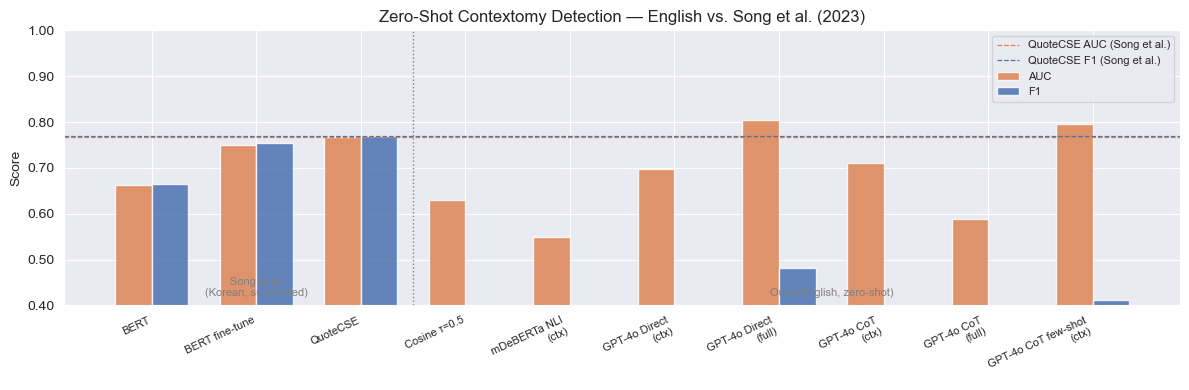

In [49]:
fig, ax = plt.subplots(figsize=(12, 4))  # slightly wider for 10 bars
x, w = np.arange(len(results)), 0.35

ax.bar(x - w/2, results['AUC'], w, label='AUC', color='#DD8452', alpha=0.85)
ax.bar(x + w/2, results['F1'],  w, label='F1',  color='#4C72B0', alpha=0.85)

ax.axhline(0.768, color='#DD8452', linestyle='--', linewidth=0.9, label='QuoteCSE AUC (Song et al.)')
ax.axhline(0.770, color='#4C72B0', linestyle='--', linewidth=0.9, label='QuoteCSE F1 (Song et al.)')
ax.axvline(2.5, color='grey', linestyle=':', linewidth=1)
ax.text(1.0, 0.42, 'Song et al.\n(Korean, supervised)', ha='center', fontsize=8, color='grey')
ax.text(6.5, 0.42, 'Ours (English, zero-shot)', ha='center', fontsize=8, color='grey')  # was 6.0

tick_labels = [
    f"{row['Method']}\n({row['Input']})" if row['Input'] != '--' else row['Method']
    for _, row in results.iterrows()
]

ax.set_xticks(x)
ax.set_xticklabels(tick_labels, rotation=25, ha='right', fontsize=8)
ax.set_ylim(0.4, 1.0)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_ylabel('Score')
ax.set_title('Zero-Shot Contextomy Detection — English vs. Song et al. (2023)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('data/results_comparison.png', dpi=150)
plt.show()

---
## Error Analysis

Error breakdown by similarity bin (low / mid / high) for the best-performing model. Reveals whether the model struggles more with subtle (mid-sim) or obvious (low-sim) contextomization.

In [50]:
# Automatically select best approach by AUC
all_approaches = {
    'cosine':    (cosine_preds,    cosine_scores,    cosine_auc),
    'nli':       (nli_preds,       nli_scores,       nli_auc),
    'gpt':       (gpt_preds,       gpt_scores,       gpt_auc),
    'gpt_full':  (gpt_full_preds,  gpt_full_scores,  gpt_full_auc),
    'cot':       (cot_preds,       cot_scores,       cot_auc),
    'cot_full':  (cot_full_preds,  cot_full_scores,  cot_full_auc),
    'fewshot':   (fewshot_preds,   fewshot_scores,   fewshot_auc),
}

best_name = max(all_approaches, key=lambda k: all_approaches[k][2])
best_preds, best_scores, _ = all_approaches[best_name]
print(f"Best approach by AUC: {best_name}")

df_eval = df.copy()
df_eval['pred']    = best_preds
df_eval['correct'] = (df_eval['pred'] == df_eval['label']).astype(int)
df_eval['error_type'] = 'correct'
df_eval.loc[(df_eval['pred']==1) & (df_eval['label']==0), 'error_type'] = 'FP'
df_eval.loc[(df_eval['pred']==0) & (df_eval['label']==1), 'error_type'] = 'FN'

print("Accuracy by similarity bin:")
print(df_eval.groupby('sim_bin')['correct'].mean().round(3))
print()

fp = df_eval[df_eval['error_type'] == 'FP']
fn = df_eval[df_eval['error_type'] == 'FN']
print(f"False Positives (predicted contextomized, was modified) : {len(fp)}")
print(f"False Negatives (predicted modified, was contextomized) : {len(fn)}")

Best approach by AUC: gpt_full
Accuracy by similarity bin:
sim_bin
high    0.774
low     0.667
mid     0.722
Name: correct, dtype: float64

False Positives (predicted contextomized, was modified) : 26
False Negatives (predicted modified, was contextomized) : 2


In [51]:
cols = ['headline_quote', 'best_body_sentence', 'best_sim', 'sim_bin', 'label', 'notes']
fn[cols].to_csv('data/false_negatives.csv', index=False)
fn[cols]

,headline_quote,best_body_sentence,best_sim,sim_bin,label,notes
54,We will pay to park outside our homes,Angry residents of Oxford Street want to be ab...,0.6474,mid,1,[hand-v2-revisit] FABRICATED 'WE' QUOTE: headl...
56,Music is what I do... whether people want it o...,“But that led to me putting things together an...,0.4941,low,1,[hand-v2] REVERSAL: body says he'll do music '...


In [52]:
# Load predictions and inspect high-confidence errors for the best approach
df_eval = pd.read_csv('data/test_set_predictions.csv')

score_col = f'score_{best_name}'
pred_col  = f'pred_{best_name}'

wrong = df_eval[df_eval[pred_col] != df_eval['label']].copy()
wrong['confidence'] = wrong[score_col].apply(lambda x: max(x, 1 - x))
wrong.sort_values('confidence', ascending=False)[
    ['headline_quote', 'best_body_sentence', 'label',
     pred_col, score_col, 'sim_bin']
].head(20)

,headline_quote,best_body_sentence,label,pred_gpt_full,score_gpt_full,sim_bin
57,"If you want to play every game, go and play fo...","“Arsene Wenger told his squad, if you want to ...",0,1,0.95,mid
93,no one cares what men do to women,No one cares what men do to you.,0,1,0.95,high
88,I nearly died of a heart attack,"DALE Fortescue ""nearly died of a heart attack”...",0,1,0.95,low
52,divorce and keep all the assets,One of Britain’s closest EU allies has likened...,0,1,0.95,low
7,I Hope You All Die at the Fucking Protests,"""I hope you all die in the fucking protests,"" ...",0,1,0.95,high
41,I will still surf on the North Coast,ROCK legend and former politician Peter Garret...,0,1,0.95,low
14,It occurred to me that I might be suffering fr...,It only slowly occurred to me that I might be ...,0,1,0.95,high
26,I ate something bad ... humans,"WEST PALM BEACH, Fla. (AP) — The Florida colle...",0,1,0.90,low
63,Everyone take a cold shower,"""The first thing I think is that everyone need...",0,1,0.90,mid
50,maddest person in room,Bill Clinton disparagingly referred to Jeremy ...,0,1,0.90,low


In [53]:
from sklearn.metrics import confusion_matrix

def sensitivity_specificity(y_true, preds):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"Sensitivity (recall on contextomized) : {sensitivity:.3f}")
    print(f"Specificity (recall on modified)       : {specificity:.3f}")
    print(f"Precision (contextomized)              : {precision:.3f}")
    return sensitivity, specificity, precision

print("=== Cosine ===")
sensitivity_specificity(y_true, cosine_preds)
print("\n=== NLI ===")
sensitivity_specificity(y_true, nli_preds)
print("\n=== GPT-4o Direct (ctx) ===")
sensitivity_specificity(y_true, gpt_preds)
print("\n=== GPT-4o Direct (full) ===")
sensitivity_specificity(y_true, gpt_full_preds)
print("\n=== GPT-4o CoT (ctx) ===")
sensitivity_specificity(y_true, cot_preds)
print("\n=== GPT-4o CoT (full) ===")
sensitivity_specificity(y_true, cot_full_preds)
print("\n=== GPT-4o CoT few-shot (ctx) ===")
sensitivity_specificity(y_true, fewshot_preds)

=== Cosine ===
Sensitivity (recall on contextomized) : 0.267
Specificity (recall on modified)       : 0.871
Precision (contextomized)              : 0.267

=== NLI ===
Sensitivity (recall on contextomized) : 0.067
Specificity (recall on modified)       : 0.894
Precision (contextomized)              : 0.100

=== GPT-4o Direct (ctx) ===
Sensitivity (recall on contextomized) : 0.800
Specificity (recall on modified)       : 0.529
Precision (contextomized)              : 0.231

=== GPT-4o Direct (full) ===
Sensitivity (recall on contextomized) : 0.867
Specificity (recall on modified)       : 0.694
Precision (contextomized)              : 0.333

=== GPT-4o CoT (ctx) ===
Sensitivity (recall on contextomized) : 0.800
Specificity (recall on modified)       : 0.600
Precision (contextomized)              : 0.261

=== GPT-4o CoT (full) ===
Sensitivity (recall on contextomized) : 0.667
Specificity (recall on modified)       : 0.482
Precision (contextomized)              : 0.185

=== GPT-4o CoT few-

(0.4666666666666667, 0.8588235294117647, 0.3684210526315789)

---
## Save All Predictions

In [54]:
df_eval['pred_cosine']      = cosine_preds
df_eval['pred_nli']         = nli_preds
df_eval['pred_gpt']         = gpt_preds
df_eval['pred_gpt_full']    = gpt_full_preds
df_eval['pred_cot']         = cot_preds
df_eval['pred_cot_full']    = cot_full_preds
df_eval['pred_fewshot']     = fewshot_preds
df_eval['score_cosine']     = cosine_scores
df_eval['score_nli']        = nli_scores
df_eval['score_gpt']        = gpt_scores
df_eval['score_gpt_full']   = gpt_full_scores
df_eval['score_cot']        = cot_scores
df_eval['score_cot_full']   = cot_full_scores
df_eval['score_fewshot']    = fewshot_scores

df_eval.to_csv('data/test_set_predictions.csv', index=False)
print("Saved: data/test_set_predictions.csv")
print()
print(results.to_string(index=False))

Saved: data/test_set_predictions.csv

             Method Input    Setting   AUC    F1
               BERT    -- supervised 0.662 0.665
     BERT fine-tune    -- supervised 0.749 0.754
           QuoteCSE    -- supervised 0.768 0.770
       Cosine τ=0.5    --  zero-shot 0.629 0.267
       mDeBERTa NLI   ctx  zero-shot 0.549 0.080
      GPT-4o Direct   ctx  zero-shot 0.697 0.358
      GPT-4o Direct  full  zero-shot 0.804 0.481
         GPT-4o CoT   ctx  zero-shot 0.710 0.393
         GPT-4o CoT  full  zero-shot 0.588 0.290
GPT-4o CoT few-shot   ctx   few-shot 0.795 0.412
